In [2]:
import pandas as pd
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Read CSV files

In [4]:
cat4_high_df = pd.read_csv('raw_inputs/c4_high_mom.csv', index_col = None)
cat4_high_df.columns = cat4_high_df.columns.str.strip()

# Format Columns and replac e defaults
cat4_high_df['Lon'] = (-1)*cat4_high_df['Lon']
cat4_high_df['Depth'] = cat4_high_df['Depth'].replace(99.9, 0.0)

## Function to create the raster from a csv

In [6]:
def create_raster_from_df(data, 
                          iname = 'I', 
                          jname = 'J',
                          LatName = 'Lat',
                          LonName = 'Lon',
                          featurename = 'Depth',
                          output_filename = 'output_depth.tif'): 

    # Extract coordinates and depth values
    points = data[[LonName, LatName]].values
    values = data[featurename].values

    # Define the raster's geographic bounds and resolution
    lat_min, lat_max = data[LatName].min(), data[LatName].max()
    lon_min, lon_max = data[LonName].min(), data[LonName].max()

    # Assuming 'I' and 'J' are your grid indices, 'Depth' is the data at each point
    i_min, i_max = data[iname].min(), data[iname].max()
    j_min, j_max = data[jname].min(), data[jname].max()
    
    # Define grid resolution (e.g., 500 x 500)
    n_rows = i_max - i_min + 1
    n_cols = j_max - j_min + 1
    # n_rows, n_cols = 500, 500
    grid_lat = np.linspace(lat_min, lat_max, n_rows)
    grid_lon = np.linspace(lon_min, lon_max, n_cols)
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)

    # Interpolate depth values onto the defined grid
    grid_depth = griddata(points, values, (grid_lon, grid_lat), method='linear')

    # Step 2: Create and save the raster with actual coordinates
    transform = from_bounds(lon_min, lat_min, lon_max, lat_max, n_cols, n_rows)
    crs = 'EPSG:4326'

    with rasterio.open(
        output_filename,
        'w',
        driver='GTiff',
        height=n_rows,
        width=n_cols,
        count=1,
        dtype=grid_depth.dtype,
        crs=crs,
        transform=transform
    ) as dst:
        dst.write(np.flipud(grid_depth), 1)

## Create and save raster files

In [8]:
# Creates the raster file and saves it to the target output location
create_raster_from_df(cat4_high_df, output_filename = 'input_data/cat4_high_raster.tif')


## Plot the raster files

In order to ensure that the raster file was created correctly, we open the raw file from the saved location, create the plots, and query values at given locations to ensure that this can be used for region risk/resilience analysis.

### Plotting the entire raster

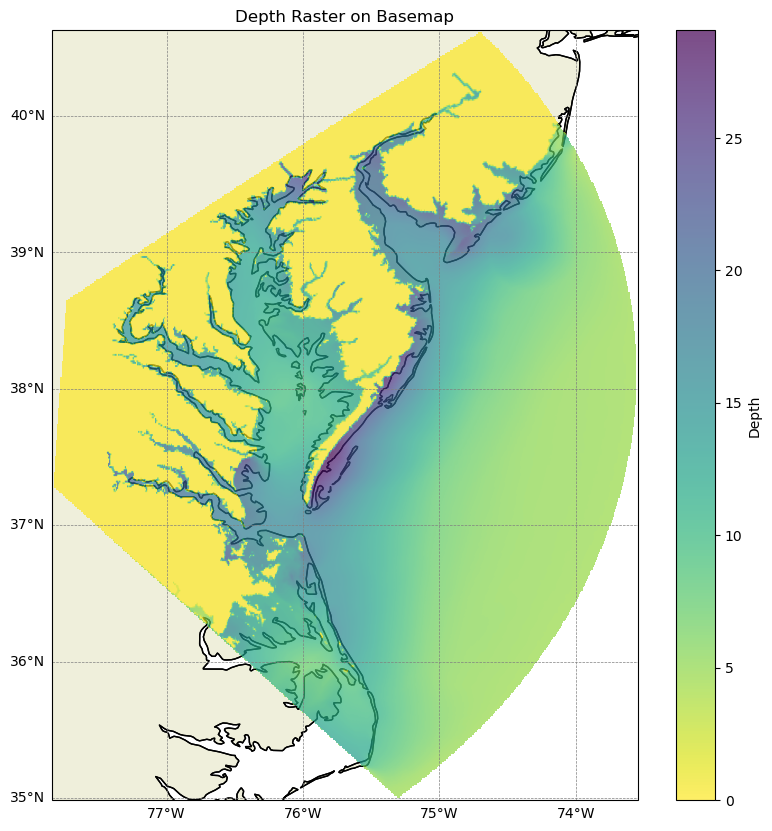

In [12]:
# Step 1: Open the raster file
raster_file = 'input_data/cat4_high_raster.tif'
with rasterio.open(raster_file) as src:
    # Read the raster data
    raster_data = src.read(1)
    # Get the extent (bounds) of the raster for plotting
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

# Step 2: Plot the raster data on a basemap
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Set the map extent to the raster bounds
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add a basemap and features
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black')
ax.add_feature(cfeature.COASTLINE, zorder=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', zorder=1)

# Plot the raster data with 'origin' set to 'upper' to align with typical raster orientation
# raster_plot = ax.imshow(np.flipud(raster_data.T), extent=extent, origin='upper', cmap='viridis', transform=ccrs.PlateCarree(), zorder=2, alpha = 0.7)
raster_plot = ax.imshow(raster_data, extent=extent, origin='upper', cmap='viridis_r', transform=ccrs.PlateCarree(), zorder=2, alpha = 0.7)

# Add a colorbar to represent depth values
cbar = plt.colorbar(raster_plot, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label('Depth')

# Set title
ax.set_title('Depth Raster on Basemap')

# Add longitude and latitude tick labels
gl = ax.gridlines(draw_labels=True, color='gray', linestyle='--', linewidth=0.5)
gl.top_labels = False  # Disable top labels
gl.right_labels = False  # Disable right labels
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Show the plot
plt.show()

### Zooming in further near region of interest

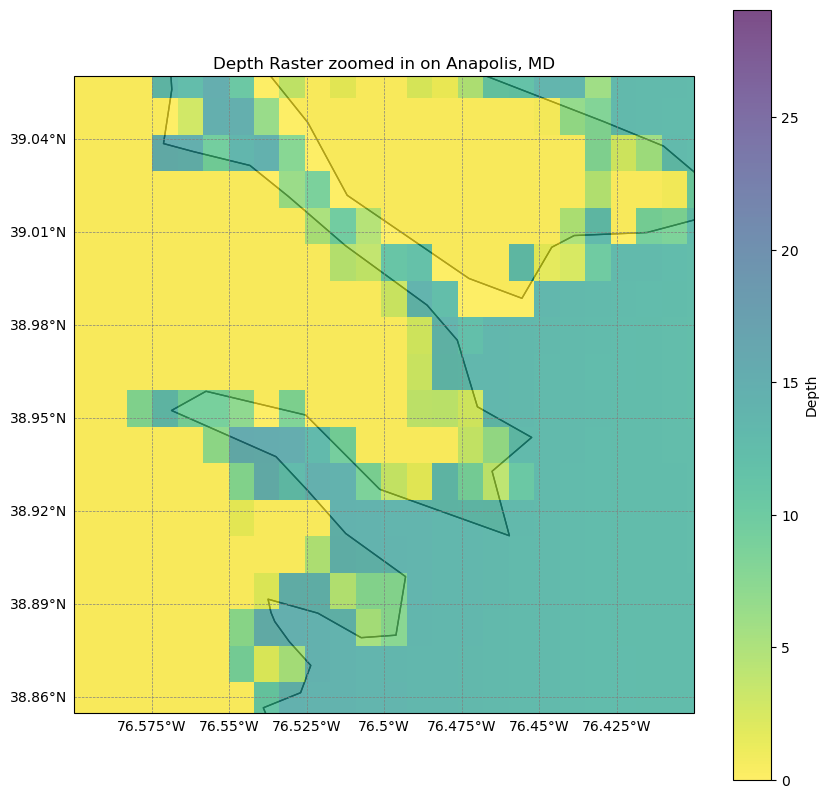

In [14]:
# Step 2: Plot the raster data on a basemap
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Set the zoomed extent (You can control the extent of interest by defining the limits of this bounding box)
ax.set_extent([-76.6, -76.4, 38.8551, 39.0603], crs=ccrs.PlateCarree())

# Add a basemap and features
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black')
ax.add_feature(cfeature.COASTLINE, zorder=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', zorder=1)

# Plot the raster data with 'origin' set to 'upper' to align with typical raster orientation
# raster_plot = ax.imshow(np.flipud(raster_data.T), extent=extent, origin='upper', cmap='viridis', transform=ccrs.PlateCarree(), zorder=2, alpha = 0.7)
raster_plot = ax.imshow(raster_data, extent=extent, origin='upper', cmap='viridis_r', transform=ccrs.PlateCarree(), zorder=2, alpha = 0.7)

# Add a colorbar to represent depth values
cbar = plt.colorbar(raster_plot, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label('Depth')

# Set title
ax.set_title('Depth Raster zoomed in on Anapolis, MD')

# Add longitude and latitude tick labels
gl = ax.gridlines(draw_labels=True, color='gray', linestyle='--', linewidth=0.5)
gl.top_labels = False  # Disable top labels
gl.right_labels = False  # Disable right labels
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Show the plot
plt.show()

## Check: Query raster value at a particular location

In [16]:
# lat, lon = 38.89, -76.4                                                             # Replace with the latitude and longitude you want to query
lat, lon = 38.98483506, -76.48653188                                                             # Replace with the latitude and longitude you want to query

with rasterio.open(raster_file) as src:
    # Convert the latitude and longitude to the raster's coordinate space and sample the depth value at this point
    for val in src.sample([(lon, lat)]):                                                 # (lon, lat) format for rasterio
        depth_value = val[0]                                                             # Retrieve the first (and only) band value
        print(f"The depth value at latitude {lat}, longitude {lon} is {depth_value} feet")

The depth value at latitude 38.98483506, longitude -76.48653188 is 14.02901377935956 feet
